# DOA Dataset Visualization Notebook

This notebook provides comprehensive visualization tools for DOA datasets generated with the simple controlled generator.

## Features:
- Load and inspect dataset structure
- Visualize individual samples (signals, steering vectors, etc.)
- Statistical analysis and histograms of all labels
- Interactive filtering and exploration
- Signal processing visualizations


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
import h5py
import json
from typing import Dict, List, Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Import the dataset class
import sys
sys.path.append('../src/data')
from dataset_generator import DOADataset
import visualization
print("Imports successful!")


Imports successful!


## 1. Load Dataset


In [2]:
# Configure dataset path
DATASET_NAME = "ula_dataset_90"  # Change this to your dataset name
DATASET_TYPE = 'linear'
DATASET_PATH = f"../Data/datasets/{DATASET_TYPE}/{DATASET_NAME}/{DATASET_NAME}.h5"

# Load dataset
dataset = DOADataset(DATASET_PATH)
print(f"Loaded dataset with {len(dataset)} samples")

# Display label summary
print("\nLabel Summary:")
for label, summary in dataset.get_label_summary().items():
    print(f"  {label}: {summary}")


Loaded dataset with 36000 samples

Label Summary:
  array_imperfections: True: 18000, False: 18000
  doas: Total DOAs: 72000, Range: [0.0, 180.0]
  num_multipath: Unique values: [0]
  num_snapshots: Unique values: [1024]
  num_sources: Unique values: [[1, 0], [1, 1], [1, 2]]
  sir: Range: [0.0, 0.0] dB, sir exists: 36000
  smr: All invalid values
  snr: Range: [-10.0, 15.0] dB, snr exists: 36000


## 2. Dataset Structure and Metadata


In [3]:
# Load dataset info
info_path = f"../Data/datasets/linear/{DATASET_NAME}/{DATASET_NAME}_info.json"
with open(info_path, 'r') as f:
    dataset_info = json.load(f)

print("Dataset Information:")
print(f"  Dataset Name: {dataset_info['dataset_name']}")
print(f"  Total Samples: {dataset_info['total_samples']:,}")
print(f"  Parameter Combinations: {dataset_info['total_combinations']:,}")
print(f"  Examples per Combination: {dataset_info['examples_per_combination']}")

print("\nParameter Ranges:")
for param, values in dataset_info['parameter_ranges'].items():
    if isinstance(values, list) and len(values) > 10:
        print(f"  {param}: [{values[0]}, ..., {values[-1]}] ({len(values)} values)")
    else:
        print(f"  {param}: {values}")

print("\nData Components:")
for component, included in dataset_info['data_components'].items():
    print(f"  {component}: {'✓' if included else '✗'}")


Dataset Information:
  Dataset Name: ula_dataset_90
  Total Samples: 36,000
  Parameter Combinations: 36
  Examples per Combination: 1000

Parameter Ranges:
  angles_deg: [90]
  snr_db: [-10, -5, 0, 5, 10, 15]
  num_snapshots: [1024]
  num_sources: [[1, 0], [1, 1], [1, 2]]
  sir_db: [0]
  num_multipath: [0]
  array_imperfections: [True, False]

Data Components:
  received_signal: ✓
  covariance_matrix: ✗
  steering_vectors: ✗
  array_metadata: ✗


## 3. Statistical Analysis - Label Distributions


In [4]:
# Extract all labels for statistical analysis
labels_df = pd.DataFrame()

for label_name, label_data in dataset.labels.items():
    if label_name == 'doas':
        # Handle variable-length DOAs - extract first DOA and number of DOAs
        first_doas = [doa[0] if len(doa) > 0 else np.nan for doa in label_data]
        num_doas = [len(doa) for doa in label_data]
        labels_df['first_doa'] = first_doas
        labels_df['num_doas'] = num_doas
    elif label_name == 'num_sources':
        # Handle 2D array - extract main and interference sources
        labels_df['main_sources'] = [sources[0] for sources in label_data]
        labels_df['interference_sources'] = [sources[1] for sources in label_data]
        labels_df['total_sources'] = [sources[0] + sources[1] for sources in label_data]
    else:
        labels_df[label_name] = label_data

print(f"Created DataFrame with {len(labels_df)} samples and {len(labels_df.columns)} features")
print("\nDataFrame Info:")
print(labels_df.info())


Created DataFrame with 36000 samples and 11 features

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   array_imperfections   36000 non-null  bool   
 1   first_doa             36000 non-null  float64
 2   num_doas              36000 non-null  int64  
 3   num_multipath         36000 non-null  int32  
 4   num_snapshots         36000 non-null  int32  
 5   main_sources          36000 non-null  int32  
 6   interference_sources  36000 non-null  int32  
 7   total_sources         36000 non-null  int32  
 8   sir                   36000 non-null  object 
 9   smr                   36000 non-null  object 
 10  snr                   36000 non-null  float32
dtypes: bool(1), float32(1), float64(1), int32(5), int64(1), object(2)
memory usage: 2.0+ MB
None


## 4. Individual Sample Visualization


Visualizing sample 0:
=== Sample 500 ===
DOAs: [90.]°
SNR: -10.0 dB
SIR: N/A (no interference) dB
Snapshots: 1024
Sources: 1 main, 0 interference
Multipath: 0
Array imperfections: True


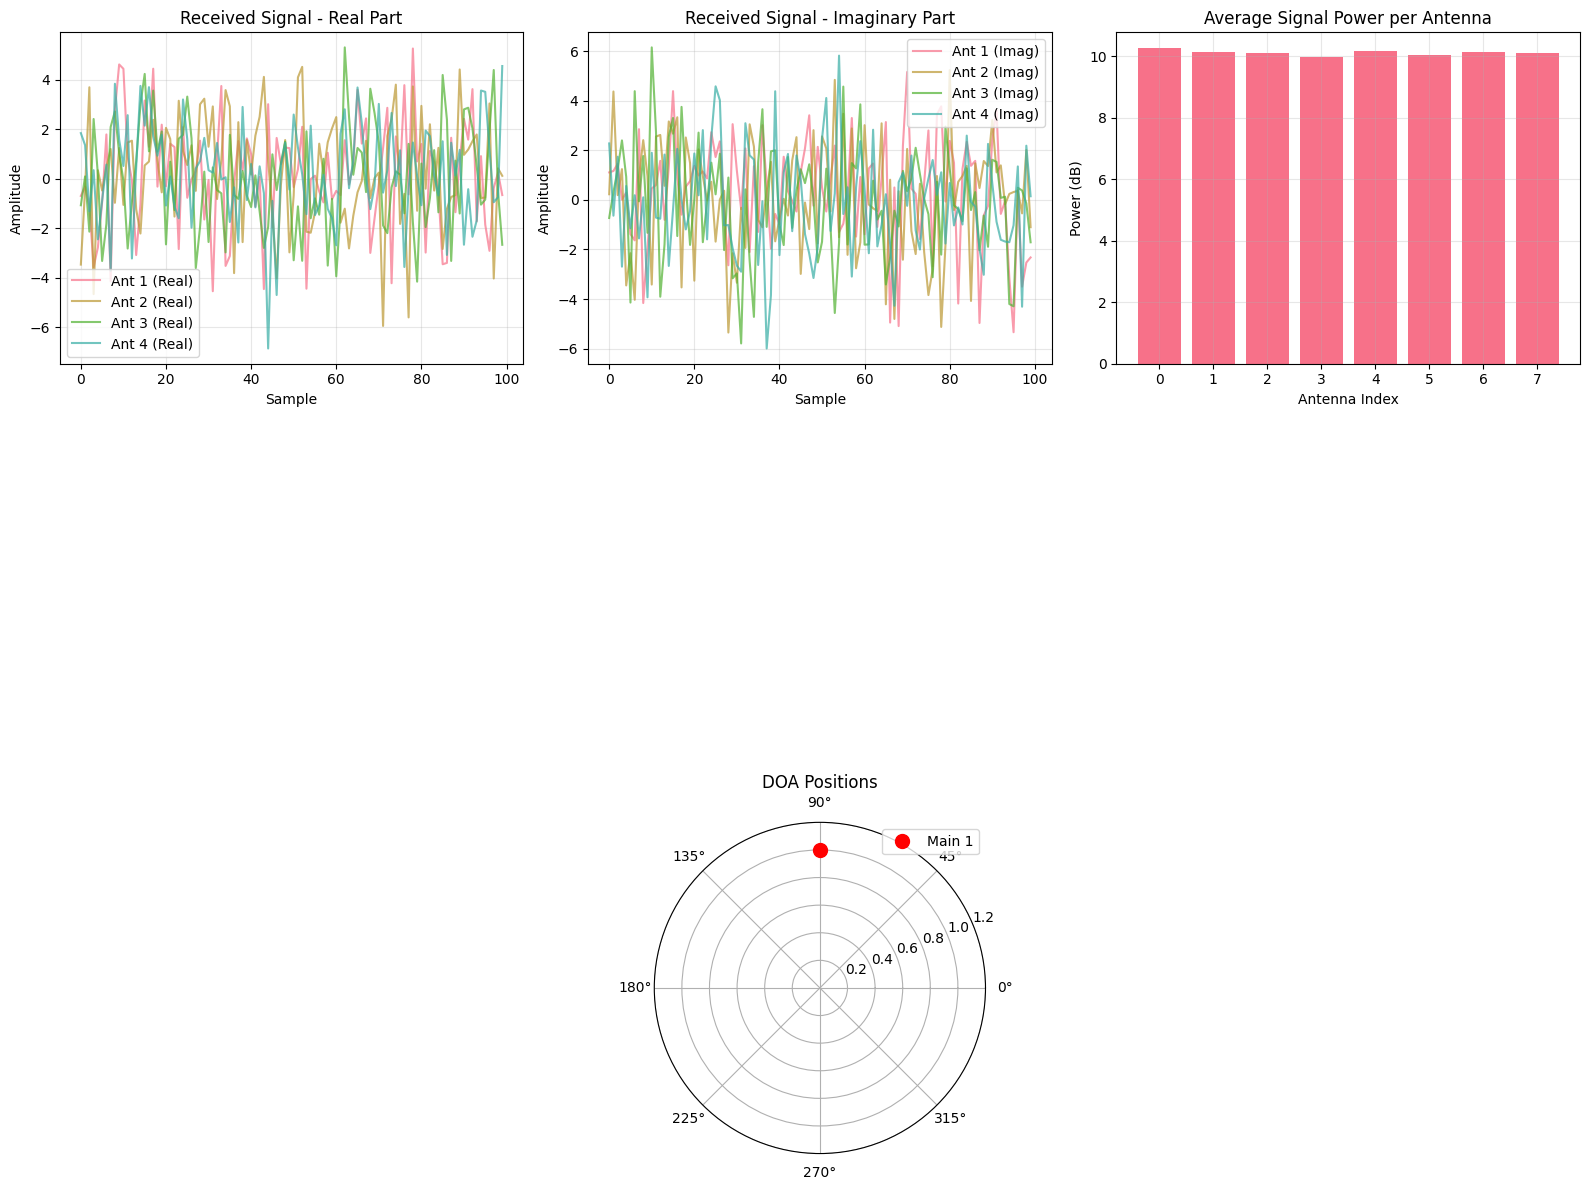

In [6]:
def visualize_sample(sample_idx: int, dataset: DOADataset):
    """Comprehensive visualization of a single sample."""
    
    # Get sample data
    sample = dataset[sample_idx]
    labels = sample['labels']
    
    print(f"=== Sample {sample_idx} ===")
    print(f"DOAs: {labels['doas']}°")
    print(f"SNR: {labels['snr']} dB")
    print(f"SIR: {labels['sir'] if labels['sir'] != -999 else 'N/A (no interference)'} dB")
    print(f"Snapshots: {labels['num_snapshots']}")
    print(f"Sources: {labels['num_sources'][0]} main, {labels['num_sources'][1]} interference")
    print(f"Multipath: {labels['num_multipath']}")
    print(f"Array imperfections: {labels['array_imperfections']}")
    
    # Create subplots
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Received Signal - Real and Imaginary parts
    if 'received_signal' in sample:
        signal = sample['received_signal'].numpy()
        
        # Plot first few snapshots of each antenna
        ax1 = plt.subplot(3, 3, 1)
        n_snapshots_to_show = min(100, signal.shape[1])
        for ant in range(min(4, signal.shape[0])):
            plt.plot(np.real(signal[ant, :n_snapshots_to_show]), 
                    label=f'Ant {ant+1} (Real)', alpha=0.7)
        plt.title('Received Signal - Real Part')
        plt.xlabel('Sample')
        plt.ylabel('Amplitude')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        ax2 = plt.subplot(3, 3, 2)
        for ant in range(min(4, signal.shape[0])):
            plt.plot(np.imag(signal[ant, :n_snapshots_to_show]), 
                    label=f'Ant {ant+1} (Imag)', alpha=0.7)
        plt.title('Received Signal - Imaginary Part')
        plt.xlabel('Sample')
        plt.ylabel('Amplitude')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 3. Signal Power across antennas
        ax3 = plt.subplot(3, 3, 3)
        signal_power = np.mean(np.abs(signal)**2, axis=1)
        plt.bar(range(len(signal_power)), 10*np.log10(signal_power))
        plt.title('Average Signal Power per Antenna')
        plt.xlabel('Antenna Index')
        plt.ylabel('Power (dB)')
        plt.grid(True, alpha=0.3)
    
    # 4. Covariance Matrix
    if 'covariance_matrix' in sample:
        cov_matrix = sample['covariance_matrix'].numpy()
        
        ax4 = plt.subplot(3, 3, 4)
        im = plt.imshow(np.abs(cov_matrix), cmap='viridis')
        plt.colorbar(im, ax=ax4)
        plt.title('Covariance Matrix Magnitude')
        plt.xlabel('Antenna')
        plt.ylabel('Antenna')
        
        ax5 = plt.subplot(3, 3, 5)
        im = plt.imshow(np.angle(cov_matrix), cmap='hsv')
        plt.colorbar(im, ax=ax5)
        plt.title('Covariance Matrix Phase')
        plt.xlabel('Antenna')
        plt.ylabel('Antenna')
    
    # 6. Steering Vectors
    if 'steering_vectors' in sample:
        steering = sample['steering_vectors']
        
        ax6 = plt.subplot(3, 3, 6)
        nominal = steering['nominal'].numpy()
        actual = steering['actual'].numpy()
        
        for i in range(nominal.shape[1]):
            plt.plot(np.abs(nominal[:, i]), 'o-', label=f'Nominal DOA {i+1}', alpha=0.7)
            plt.plot(np.abs(actual[:, i]), 's--', label=f'Actual DOA {i+1}', alpha=0.7)
        plt.title('Steering Vector Magnitudes')
        plt.xlabel('Antenna')
        plt.ylabel('Magnitude')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        ax7 = plt.subplot(3, 3, 7)
        for i in range(nominal.shape[1]):
            plt.plot(np.angle(nominal[:, i]), 'o-', label=f'Nominal DOA {i+1}', alpha=0.7)
            plt.plot(np.angle(actual[:, i]), 's--', label=f'Actual DOA {i+1}', alpha=0.7)
        plt.title('Steering Vector Phases')
        plt.xlabel('Antenna')
        plt.ylabel('Phase (rad)')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    # 8. DOA Visualization (polar plot)
    ax8 = plt.subplot(3, 3, 8, projection='polar')
    doas_rad = np.deg2rad(labels['doas'])
    
    # Plot DOAs
    for i, doa in enumerate(doas_rad):
        if i < labels['num_sources'][0]:  # Main sources
            ax8.plot(doa, 1, 'ro', markersize=10, label=f'Main {i+1}' if i == 0 else '')
        else:  # Interference sources
            ax8.plot(doa, 1, 'bs', markersize=8, label=f'Interference {i-labels["num_sources"][0]+1}' if i == labels['num_sources'][0] else '')
    
    ax8.set_ylim(0, 1.2)
    ax8.set_title('DOA Positions')
    ax8.legend()
    
    # 9. Eigenvalue decomposition of covariance matrix
    if 'covariance_matrix' in sample:
        ax9 = plt.subplot(3, 3, 9)
        eigenvals = np.linalg.eigvals(cov_matrix)
        eigenvals_sorted = np.sort(np.real(eigenvals))[::-1]
        
        plt.semilogy(eigenvals_sorted, 'o-')
        plt.title('Eigenvalue Spectrum')
        plt.xlabel('Eigenvalue Index')
        plt.ylabel('Eigenvalue Magnitude')
        plt.grid(True, alpha=0.3)
        
        # Add vertical line at number of sources
        total_sources = labels['num_sources'][0] + labels['num_sources'][1]
        plt.axvline(x=total_sources-1, color='red', linestyle='--', alpha=0.7, label=f'Sources: {total_sources}')
        plt.legend()
    
    plt.tight_layout()
    plt.show()

# Visualize a few sample examples
print("Visualizing sample 0:")
visualize_sample(500, dataset)


(8, 8)

Main eigenvalue: 12.288252
Sum of smaller eigenvalues: 69.823086
Ratio (main/smaller): 0.175991
Ratio in dB: -7.55 dB


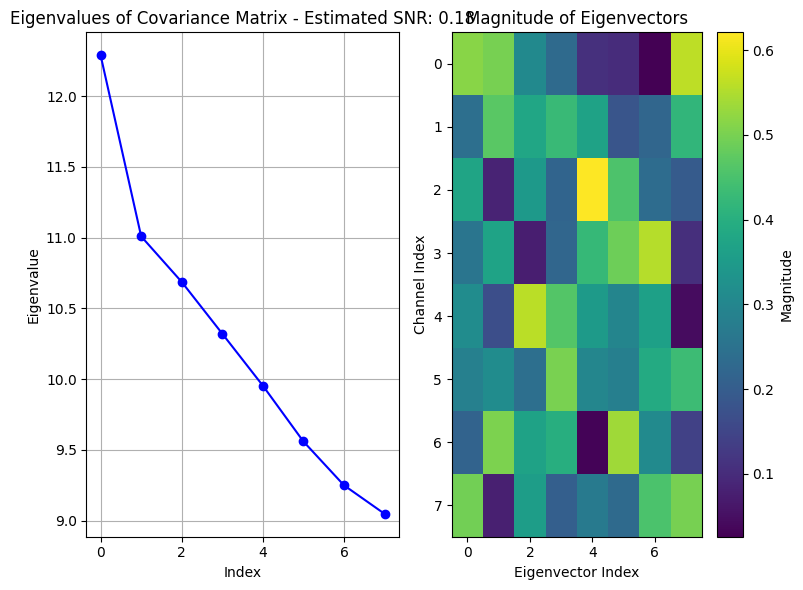

In [7]:
import visualization.recieved_signal_plotting


sample = dataset[500]
if 'received_signal' in sample:
    signal = sample['received_signal'].numpy()
visualization.recieved_signal_plotting.plot_eigenvalue_analysis(signal, 1)

## 5. Interactive Sample Explorer

Change the sample index below to explore different samples:


=== Sample 398 ===
DOAs: [ 0.         86.23901367 36.1475296 ]°
SNR: -9.0 dB
SIR: [0.] dB
Snapshots: 1024
Sources: 1 main, 1 interference
Multipath: 1
Array imperfections: False


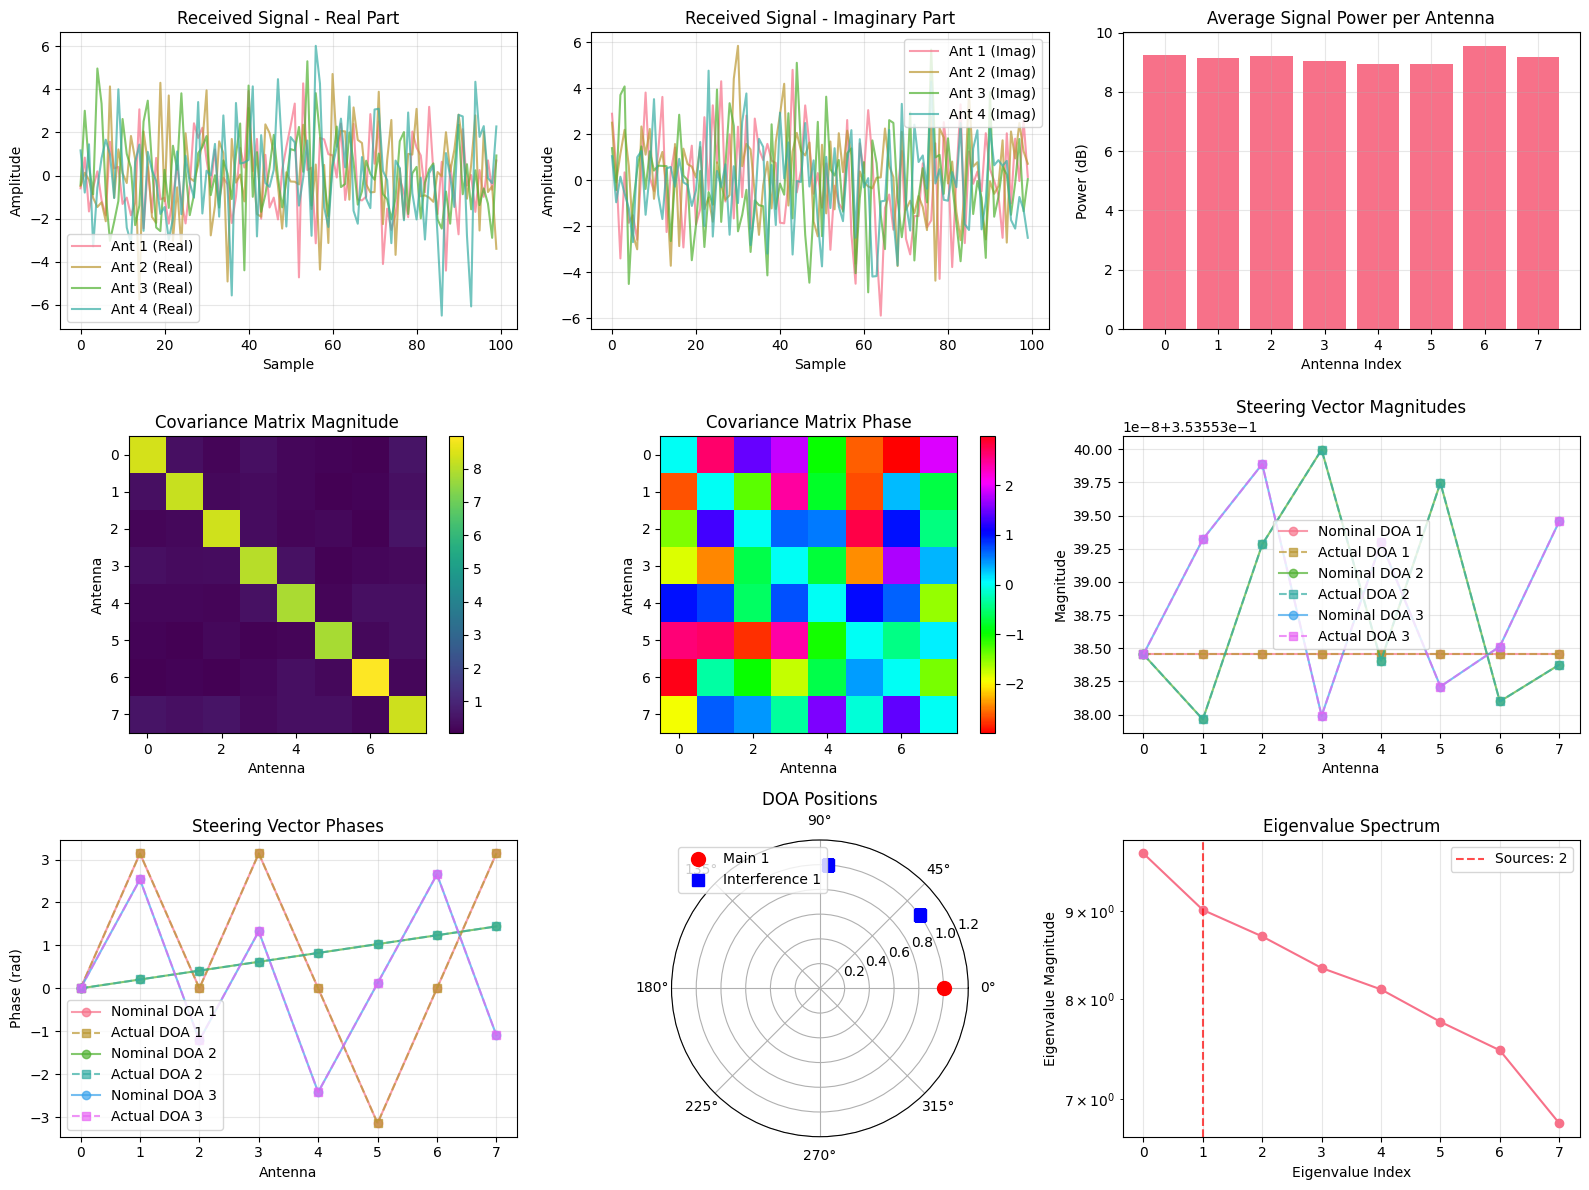

In [13]:
# Change this index to explore different samples
SAMPLE_TO_EXPLORE = 398  # Change this number (0 to len(dataset)-1)

if SAMPLE_TO_EXPLORE < len(dataset):
    visualize_sample(SAMPLE_TO_EXPLORE, dataset)
else:
    print(f"Invalid sample index. Please choose between 0 and {len(dataset)-1}")


## 6. Filtered Dataset Analysis

Explore specific subsets of your dataset:


=== Filtered Dataset Analysis ===

High SNR samples (10 dB): 43200
Single source scenarios: 561600
Two source scenarios (1 main + 1 interference): 374400
Samples with array imperfections: 561600
Challenging scenarios (Low SNR + Interference): 80

=== Sample from High SNR category ===
=== Sample 0 ===
DOAs: [0.]°
SNR: 10.0 dB
SIR: N/A (no interference) dB
Snapshots: 1024
Sources: 1 main, 0 interference
Multipath: 0
Array imperfections: True


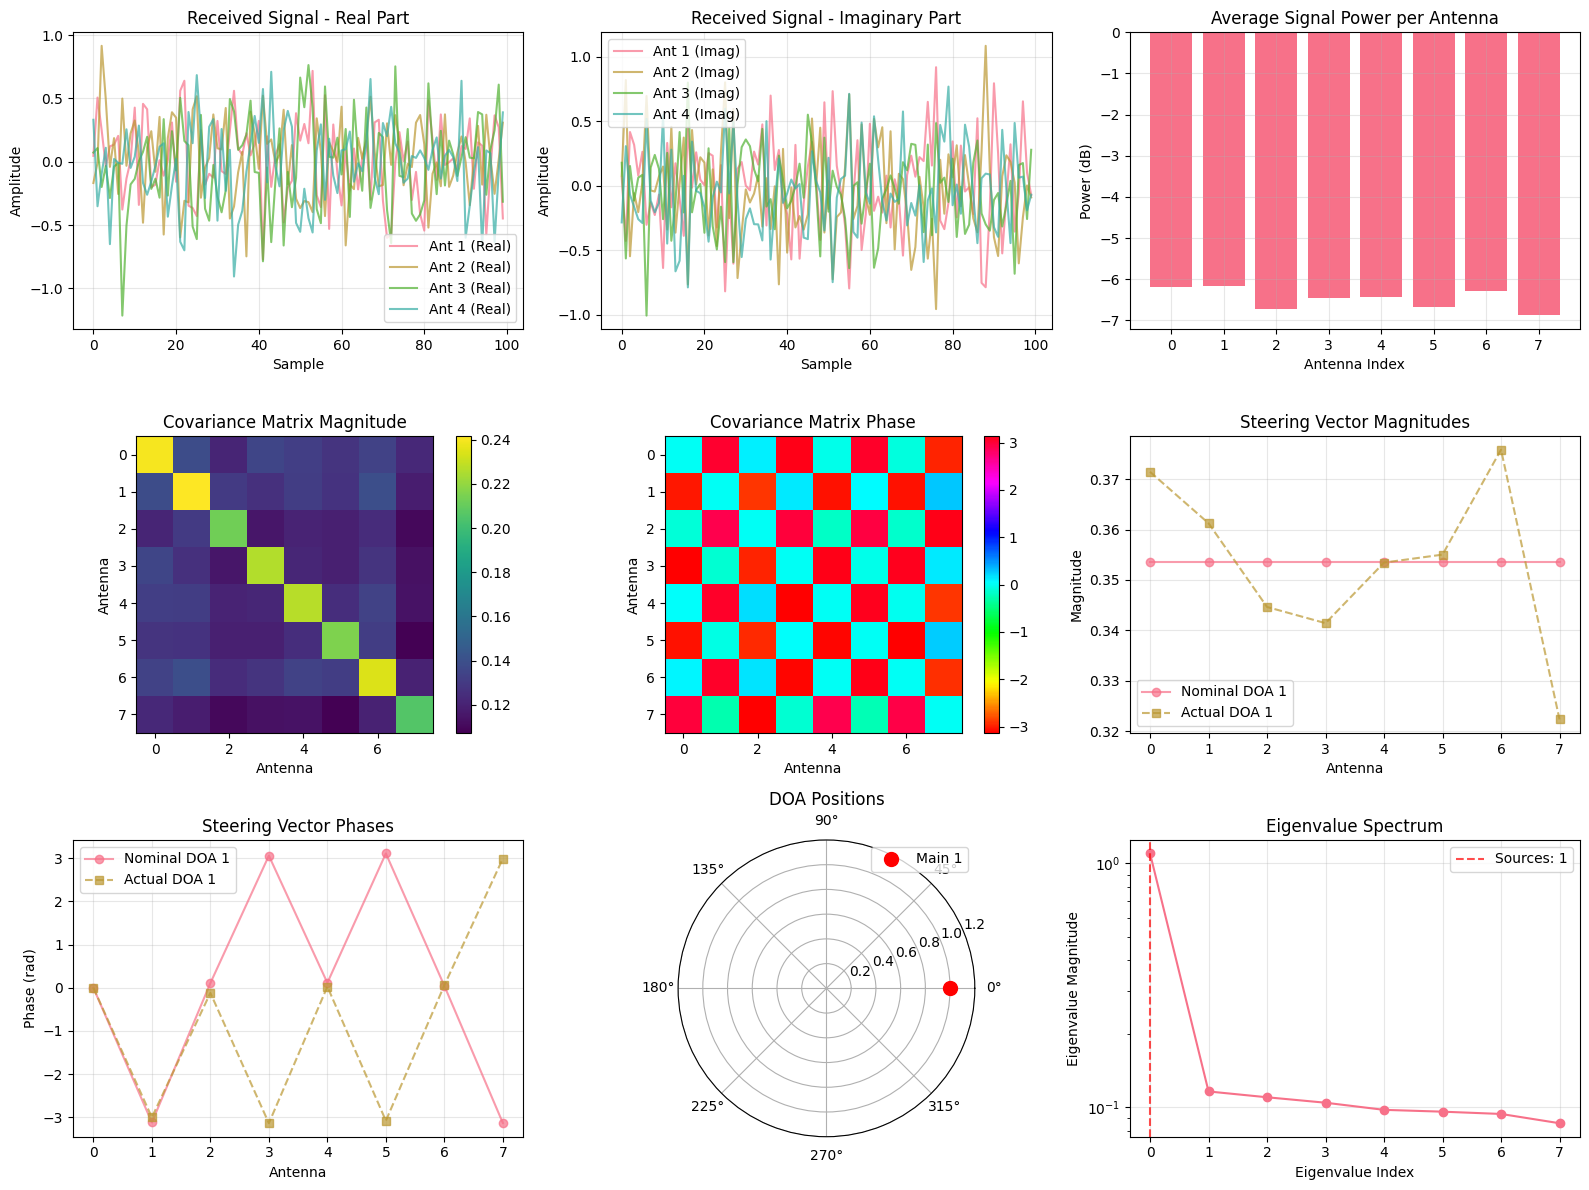

In [14]:
# Example filtered analyses
print("=== Filtered Dataset Analysis ===")

# High SNR samples
high_snr = dataset.filter(snr=10.0)
print(f"\nHigh SNR samples (10 dB): {len(high_snr)}")

# Single source scenarios
single_source = dataset.filter(num_sources=[1, 0])
print(f"Single source scenarios: {len(single_source)}")

# Multiple source scenarios
multi_source = dataset.filter(num_sources=[1, 1])
print(f"Two source scenarios (1 main + 1 interference): {len(multi_source)}")

# Array imperfections
imperfect_arrays = dataset.filter(array_imperfections=True)
print(f"Samples with array imperfections: {len(imperfect_arrays)}")

# Low SNR with interference
challenging = dataset.filter(snr=-10.0, num_sources=[1, 1], doas=90)
print(f"Challenging scenarios (Low SNR + Interference): {len(challenging)}")

# Visualize a sample from each category
print("\n=== Sample from High SNR category ===")
if len(high_snr) > 0:
    visualize_sample(0, high_snr)


## 7. Comparison Between Different Scenarios


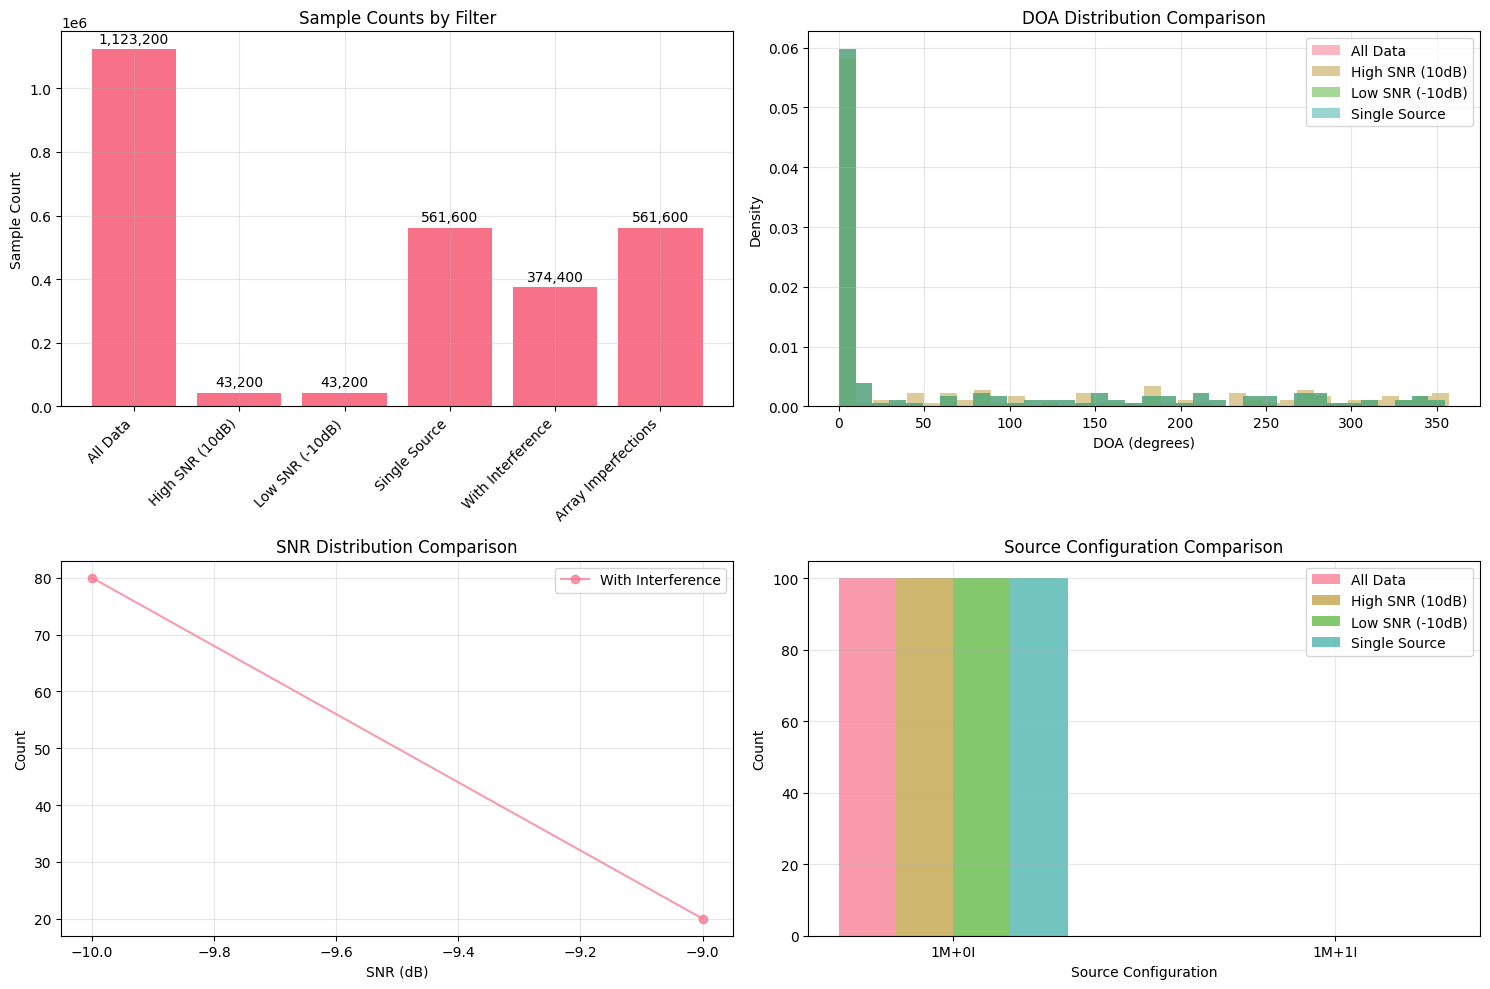

In [ ]:
# Compare distributions between filtered datasets
def compare_filtered_datasets():
    """Compare distributions between different filtered datasets."""
    
    # Create comparison datasets
    datasets_to_compare = {
        'All Data': dataset,
        'High SNR (10dB)': dataset.filter(snr=10.0),
        'Low SNR (-10dB)': dataset.filter(snr=-10.0),
        'Single Source': dataset.filter(num_sources=[1, 0]),
        'With Interference': dataset.filter(num_sources=[1, 1]),
        'Array Imperfections': dataset.filter(array_imperfections=True)
    }
    
    # Create comparison plots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Sample counts
    ax1 = axes[0, 0]
    names = list(datasets_to_compare.keys())
    counts = [len(ds) for ds in datasets_to_compare.values()]
    
    bars = ax1.bar(range(len(names)), counts)
    ax1.set_xticks(range(len(names)))
    ax1.set_xticklabels(names, rotation=45, ha='right')
    ax1.set_ylabel('Sample Count')
    ax1.set_title('Sample Counts by Filter')
    ax1.grid(True, alpha=0.3)
    
    # Add count labels on bars
    for bar, count in zip(bars, counts):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                f'{count:,}', ha='center', va='bottom')
    
    # 2. DOA distribution comparison
    ax2 = axes[0, 1]
    for name, ds in list(datasets_to_compare.items())[:4]:  # First 4 to avoid overcrowding
        if len(ds) > 0:
            # Get all DOAs from this filtered dataset
            all_doas = []
            for i in range(min(100, len(ds))):  # Sample first 100 for speed
                sample = ds[i]
                all_doas.extend(sample['labels']['doas'])
            
            if all_doas:
                ax2.hist(all_doas, bins=36, alpha=0.5, label=name, density=True)
    
    ax2.set_xlabel('DOA (degrees)')
    ax2.set_ylabel('Density')
    ax2.set_title('DOA Distribution Comparison')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. SNR distribution comparison
    ax3 = axes[1, 0]
    for name, ds in datasets_to_compare.items():
        if len(ds) > 0:
            snr_values = [ds[i]['labels']['snr'] for i in range(min(100, len(ds)))]
            unique_snrs = np.unique(snr_values)
            if len(unique_snrs) > 1:  # Only plot if there's variation
                counts = [snr_values.count(snr) for snr in unique_snrs]
                ax3.plot(unique_snrs, counts, 'o-', label=name, alpha=0.7)
    
    ax3.set_xlabel('SNR (dB)')
    ax3.set_ylabel('Count')
    ax3.set_title('SNR Distribution Comparison')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Source configuration comparison
    ax4 = axes[1, 1]
    source_configs = {}
    
    for name, ds in datasets_to_compare.items():
        if len(ds) > 0:
            configs = []
            for i in range(min(100, len(ds))):
                sample = ds[i]
                main, interference = sample['labels']['num_sources']
                configs.append(f"{main}M+{interference}I")
            
            unique_configs = list(set(configs))
            config_counts = [configs.count(config) for config in unique_configs]
            source_configs[name] = dict(zip(unique_configs, config_counts))
    
    # Plot source configurations
    all_configs = set()
    for configs in source_configs.values():
        all_configs.update(configs.keys())
    all_configs = sorted(all_configs)
    
    x = np.arange(len(all_configs))
    width = 0.15
    
    for i, (name, configs) in enumerate(list(source_configs.items())[:4]):
        counts = [configs.get(config, 0) for config in all_configs]
        ax4.bar(x + i*width, counts, width, label=name, alpha=0.7)
    
    ax4.set_xlabel('Source Configuration')
    ax4.set_ylabel('Count')
    ax4.set_title('Source Configuration Comparison')
    ax4.set_xticks(x + width * 1.5)
    ax4.set_xticklabels(all_configs)
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

compare_filtered_datasets()


## 8. Signal Quality Analysis


=== Signal Quality Analysis ===


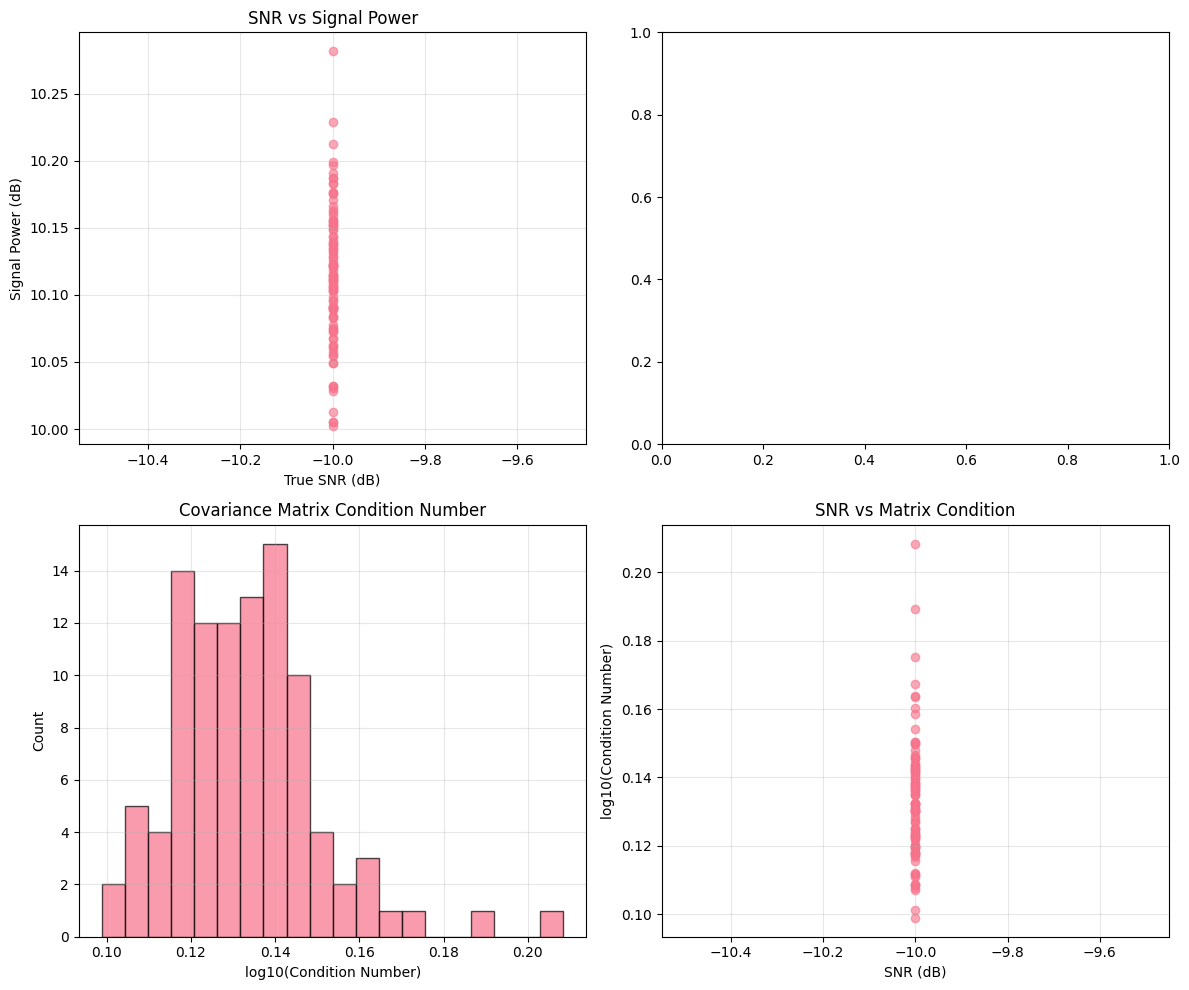


Signal Quality Statistics (from 100 samples):
  SNR range: [-10.0, -10.0] dB
  Signal power range: [10.0, 10.3] dB
  Condition number range: [1.3e+00, 1.6e+00]


In [ ]:
def analyze_signal_quality(dataset, num_samples=100):
    """Analyze signal quality metrics across the dataset."""
    
    print("=== Signal Quality Analysis ===")
    
    snr_values = []
    sir_values = []
    signal_powers = []
    condition_numbers = []
    
    for i in range(min(num_samples, len(dataset))):
        sample = dataset[i]
        labels = sample['labels']
        
        snr_values.append(labels['snr'])
        if labels['sir'] != -999:
            sir_values.append(labels['sir'])
        
        if 'received_signal' in sample:
            signal = sample['received_signal'].numpy()
            signal_powers.append(np.mean(np.abs(signal)**2))
        
        if 'covariance_matrix' in sample:
            cov = sample['covariance_matrix'].numpy()
            eigenvals = np.linalg.eigvals(cov)
            eigenvals = np.real(eigenvals[eigenvals > 0])
            if len(eigenvals) > 1:
                condition_numbers.append(np.max(eigenvals) / np.min(eigenvals))
    
    # Plot quality metrics
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # SNR vs Signal Power
    axes[0, 0].scatter(snr_values, 10*np.log10(signal_powers), alpha=0.6)
    axes[0, 0].set_xlabel('True SNR (dB)')
    axes[0, 0].set_ylabel('Signal Power (dB)')
    axes[0, 0].set_title('SNR vs Signal Power')
    axes[0, 0].grid(True, alpha=0.3)
    
    # SIR distribution
    if sir_values:
        axes[0, 1].hist(sir_values, bins=20, alpha=0.7, edgecolor='black')
        axes[0, 1].set_xlabel('SIR (dB)')
        axes[0, 1].set_ylabel('Count')
        axes[0, 1].set_title('SIR Distribution')
        axes[0, 1].grid(True, alpha=0.3)
    
    # Condition number distribution
    if condition_numbers:
        axes[1, 0].hist(np.log10(condition_numbers), bins=20, alpha=0.7, edgecolor='black')
        axes[1, 0].set_xlabel('log10(Condition Number)')
        axes[1, 0].set_ylabel('Count')
        axes[1, 0].set_title('Covariance Matrix Condition Number')
        axes[1, 0].grid(True, alpha=0.3)
    
    # SNR vs Condition Number
    if condition_numbers:
        axes[1, 1].scatter(snr_values[:len(condition_numbers)], np.log10(condition_numbers), alpha=0.6)
        axes[1, 1].set_xlabel('SNR (dB)')
        axes[1, 1].set_ylabel('log10(Condition Number)')
        axes[1, 1].set_title('SNR vs Matrix Condition')
        axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nSignal Quality Statistics (from {num_samples} samples):")
    print(f"  SNR range: [{min(snr_values):.1f}, {max(snr_values):.1f}] dB")
    if sir_values:
        print(f"  SIR range: [{min(sir_values):.1f}, {max(sir_values):.1f}] dB")
    if signal_powers:
        print(f"  Signal power range: [{10*np.log10(min(signal_powers)):.1f}, {10*np.log10(max(signal_powers)):.1f}] dB")
    if condition_numbers:
        print(f"  Condition number range: [{min(condition_numbers):.1e}, {max(condition_numbers):.1e}]")

analyze_signal_quality(dataset)


## 9. Export Summary and Usage Examples

### Quick Usage Examples:

```python
# Load a different dataset
dataset = DOADataset('../Data/datasets/your_dataset/your_dataset.h5')

# Filter for specific conditions
high_snr_single = dataset.filter(snr=10.0, num_sources=[1, 0])
challenging = dataset.filter(snr=-10.0, array_imperfections=True)

# Visualize specific samples
visualize_sample(42, dataset)

# Analyze signal quality
analyze_signal_quality(dataset, num_samples=500)
```

### Tips:
1. **Memory Management**: For large datasets, use filtered subsets for analysis
2. **Visualization**: Adjust `n_snapshots_to_show` in `visualize_sample()` for different signal lengths
3. **Performance**: Reduce `num_samples` in analysis functions for faster execution
4. **Filtering**: Combine multiple filter conditions for specific scenario analysis
